In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

from model.model import KohonenNetwork

In [2]:
def load_and_prepare_data(file_path, is_3d=False):
    """
    Loads the dataset from a CSV file and separates features from labels.
    This ensures that the SOM only trains on coordinates, not class labels.

    Parameters:
    - file_path: String, path to the CSV file.
    - is_3d: Boolean, indicates if the data has 3 dimensions (x, y, z)
             or 2 dimensions (x, y).

    Returns:
    - features: A 2D numpy array containing only the coordinates.
    - labels: A 1D numpy array containing the class identifiers (column 'c').
    """
    # 1. Load the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # 2. Extract features depending on the dataset dimensions
    if is_3d:
        # For 'cube.csv': select only 'x', 'y', 'z' columns
        features = df[['x', 'y', 'z']].values
    else:
        # For 'hexagon.csv': select only 'x', 'y' columns
        features = df[['x', 'y']].values

    # 3. Extract the class labels (column 'c') for later evaluation
    labels = df['c'].values

    return features, labels

In [3]:
def plot_som_2d(data, weights, title="SOM 2D Projection"):
    """
    Visualizes the SOM grid over 2D data.

    Parameters:
    - data: 2D numpy array of the input data (features only).
    - weights: 3D numpy array of the SOM weights (M, N, 2).
    - title: Title of the plot.
    """
    plt.figure(figsize=(8, 8))

    # 1. Plot the original data points
    plt.scatter(data[:, 0], data[:, 1], c='lightblue', alpha=0.6, s=20, label='Data Points')

    # 2. Plot the SOM grid (wireframe)
    M, N, _ = weights.shape

    # Draw horizontal lines connecting neurons
    for i in range(M):
        plt.plot(weights[i, :, 0], weights[i, :, 1], color='black', alpha=0.7, linewidth=1)

    # Draw vertical lines connecting neurons
    for j in range(N):
        plt.plot(weights[:, j, 0], weights[:, j, 1], color='black', alpha=0.7, linewidth=1)

    # 3. Plot the neurons themselves as distinct points
    plt.scatter(weights[:, :, 0].flatten(), weights[:, :, 1].flatten(),
                c='red', s=30, zorder=5, label='SOM Neurons')

    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_som_3d(data, weights, title="SOM 3D Projection"):
    """
    Visualizes the SOM grid over 3D data.

    Parameters:
    - data: 2D numpy array of the input data (features only).
    - weights: 3D numpy array of the SOM weights (M, N, 3).
    - title: Title of the plot.
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the original 3D data points
    ax.scatter(data[:, 0], data[:, 1], data[:, 2],
               c='lightblue', alpha=0.4, s=15, label='Data Points')

    # 2. Plot the SOM grid (wireframe)
    M, N, _ = weights.shape

    # Draw horizontal lines connecting neurons
    for i in range(M):
        ax.plot(weights[i, :, 0], weights[i, :, 1], weights[i, :, 2],
                color='black', alpha=0.7, linewidth=1)

    # Draw vertical lines connecting neurons
    for j in range(N):
        ax.plot(weights[:, j, 0], weights[:, j, 1], weights[:, j, 2],
                color='black', alpha=0.7, linewidth=1)

    # 3. Plot the neurons
    ax.scatter(weights[:, :, 0].flatten(), weights[:, :, 1].flatten(), weights[:, :, 2].flatten(),
               c='red', s=30, zorder=5, label='SOM Neurons')

    ax.set_title(title)
    ax.legend()
    plt.show()

In [4]:
# 1. Load the Hexagon dataset (2D)
hexagon_features, hexagon_labels = load_and_prepare_data('C:/Users/Wojtek/Documents/MIO/SOM/datasets/hexagon.csv', is_3d=False)
print(f"Hexagon features shape: {hexagon_features.shape}")
print(f"Hexagon labels shape: {hexagon_labels.shape}\n")

# 2. Load the Cube dataset (3D)
cube_features, cube_labels = load_and_prepare_data('C:/Users/Wojtek/Documents/MIO/SOM/datasets/cube.csv', is_3d=True)
print(f"Cube features shape: {cube_features.shape}")
print(f"Cube labels shape: {cube_labels.shape}")

Hexagon features shape: (600, 2)
Hexagon labels shape: (600,)

Cube features shape: (1200, 3)
Cube labels shape: (1200,)


Używamy dwóch heurestyk (Wzór Vesanto)

$$
\text{Liczba neuronów} \approx 5 \sqrt{\text{Liczba wszystkich danych}}
$$

oraz:

$$
\lambda = \frac{\text{Liczba wszystkich iteracji}}{2}
$$

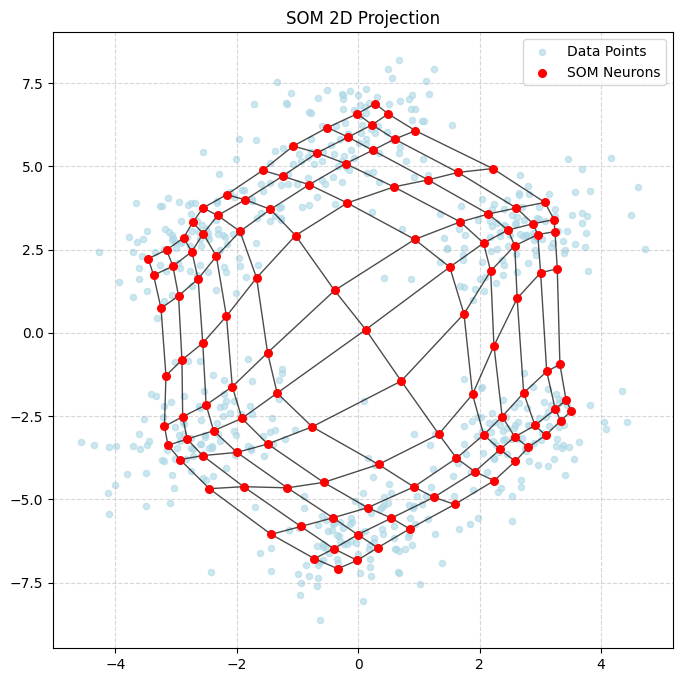

In [7]:
som_hexagon = KohonenNetwork(grid_shape=(11, 11), input_dim=2, lambda_param=30000)

som_hexagon.train(data=hexagon_features, num_epochs=100, sigma=1)

hexagon_predictions = som_hexagon.predict(data=hexagon_features)

plot_som_2d(hexagon_features, som_hexagon.weights)

In [8]:
def evaluate_som_clusters(predictions, true_labels):
    bmu_clusters = defaultdict(list)
    for bmu, label in zip(predictions, true_labels):
        # Convert NumPy types to standard Python ints for cleaner output
        bmu_key = (int(bmu[0]), int(bmu[1]))
        bmu_clusters[bmu_key].append(int(label))

    total_samples = len(true_labels)
    total_correct = 0
    cluster_info = {}

    # Sort keys (coordinates) to make the report easier to read
    sorted_bmus = sorted(bmu_clusters.keys())

    print(f"Total active neurons: {len(bmu_clusters)}\n")

    for bmu in sorted_bmus:
        labels_in_neuron = bmu_clusters[bmu]
        label_counts = Counter(labels_in_neuron)

        majority_class, majority_count = label_counts.most_common(1)[0]
        total_correct += majority_count

        neuron_purity = (majority_count / len(labels_in_neuron)) * 100
        cluster_info[bmu] = dict(label_counts)

        print(f"Neuron {bmu}: {len(labels_in_neuron)} samples, Purity: {neuron_purity:.2f}% | Counts: {dict(label_counts)}")

    overall_purity = total_correct / total_samples
    print("-" * 30)
    print(f"OVERALL NETWORK PURITY: {overall_purity * 100:.2f}%")

    return cluster_info, overall_purity

In [9]:
info, purity = evaluate_som_clusters(hexagon_predictions, true_labels=hexagon_labels)

Total active neurons: 114

Neuron (0, 0): 17 samples, Purity: 100.00% | Counts: {0: 17}
Neuron (0, 1): 4 samples, Purity: 100.00% | Counts: {0: 4}
Neuron (0, 2): 4 samples, Purity: 100.00% | Counts: {0: 4}
Neuron (0, 3): 2 samples, Purity: 100.00% | Counts: {1: 2}
Neuron (0, 4): 10 samples, Purity: 100.00% | Counts: {1: 10}
Neuron (0, 5): 7 samples, Purity: 100.00% | Counts: {1: 7}
Neuron (0, 6): 7 samples, Purity: 100.00% | Counts: {1: 7}
Neuron (0, 7): 4 samples, Purity: 100.00% | Counts: {1: 4}
Neuron (0, 8): 1 samples, Purity: 100.00% | Counts: {2: 1}
Neuron (0, 9): 8 samples, Purity: 100.00% | Counts: {2: 8}
Neuron (0, 10): 4 samples, Purity: 100.00% | Counts: {2: 4}
Neuron (1, 0): 8 samples, Purity: 100.00% | Counts: {0: 8}
Neuron (1, 1): 4 samples, Purity: 100.00% | Counts: {0: 4}
Neuron (1, 2): 4 samples, Purity: 100.00% | Counts: {0: 4}
Neuron (1, 4): 7 samples, Purity: 100.00% | Counts: {1: 7}
Neuron (1, 5): 3 samples, Purity: 100.00% | Counts: {1: 3}
Neuron (1, 6): 9 samples

In [10]:
def plot_som_2d_on_axis(ax, data, weights, title="SOM 2D Projection"):
    """
    Visualizes the SOM grid over 2D data on a specific matplotlib axis.
    This allows plotting multiple SOMs side-by-side.

    Parameters:
    - ax: The matplotlib Axis object to draw on.
    - data: 2D numpy array of the input data.
    - weights: 3D numpy array of the SOM weights.
    - title: Title for this specific subplot.
    """
    # 1. Plot the original data points
    ax.scatter(data[:, 0], data[:, 1], c='lightblue', alpha=0.6, s=20)

    # 2. Plot the SOM grid (wireframe)
    M, N, _ = weights.shape

    for i in range(M):
        ax.plot(weights[i, :, 0], weights[i, :, 1], color='black', alpha=0.7, linewidth=1)

    for j in range(N):
        ax.plot(weights[:, j, 0], weights[:, j, 1], color='black', alpha=0.7, linewidth=1)

    # 3. Plot the neurons
    ax.scatter(weights[:, :, 0].flatten(), weights[:, :, 1].flatten(),
               c='red', s=30, zorder=5)

    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)

Training SOM with sigma = 0.1...
Training SOM with sigma = 0.5...
Training SOM with sigma = 0.8...
Training SOM with sigma = 1.0...
Training SOM with sigma = 2.0...
Training SOM with sigma = 3.5...
Training SOM with sigma = 5.0...
Training SOM with sigma = 10.0...


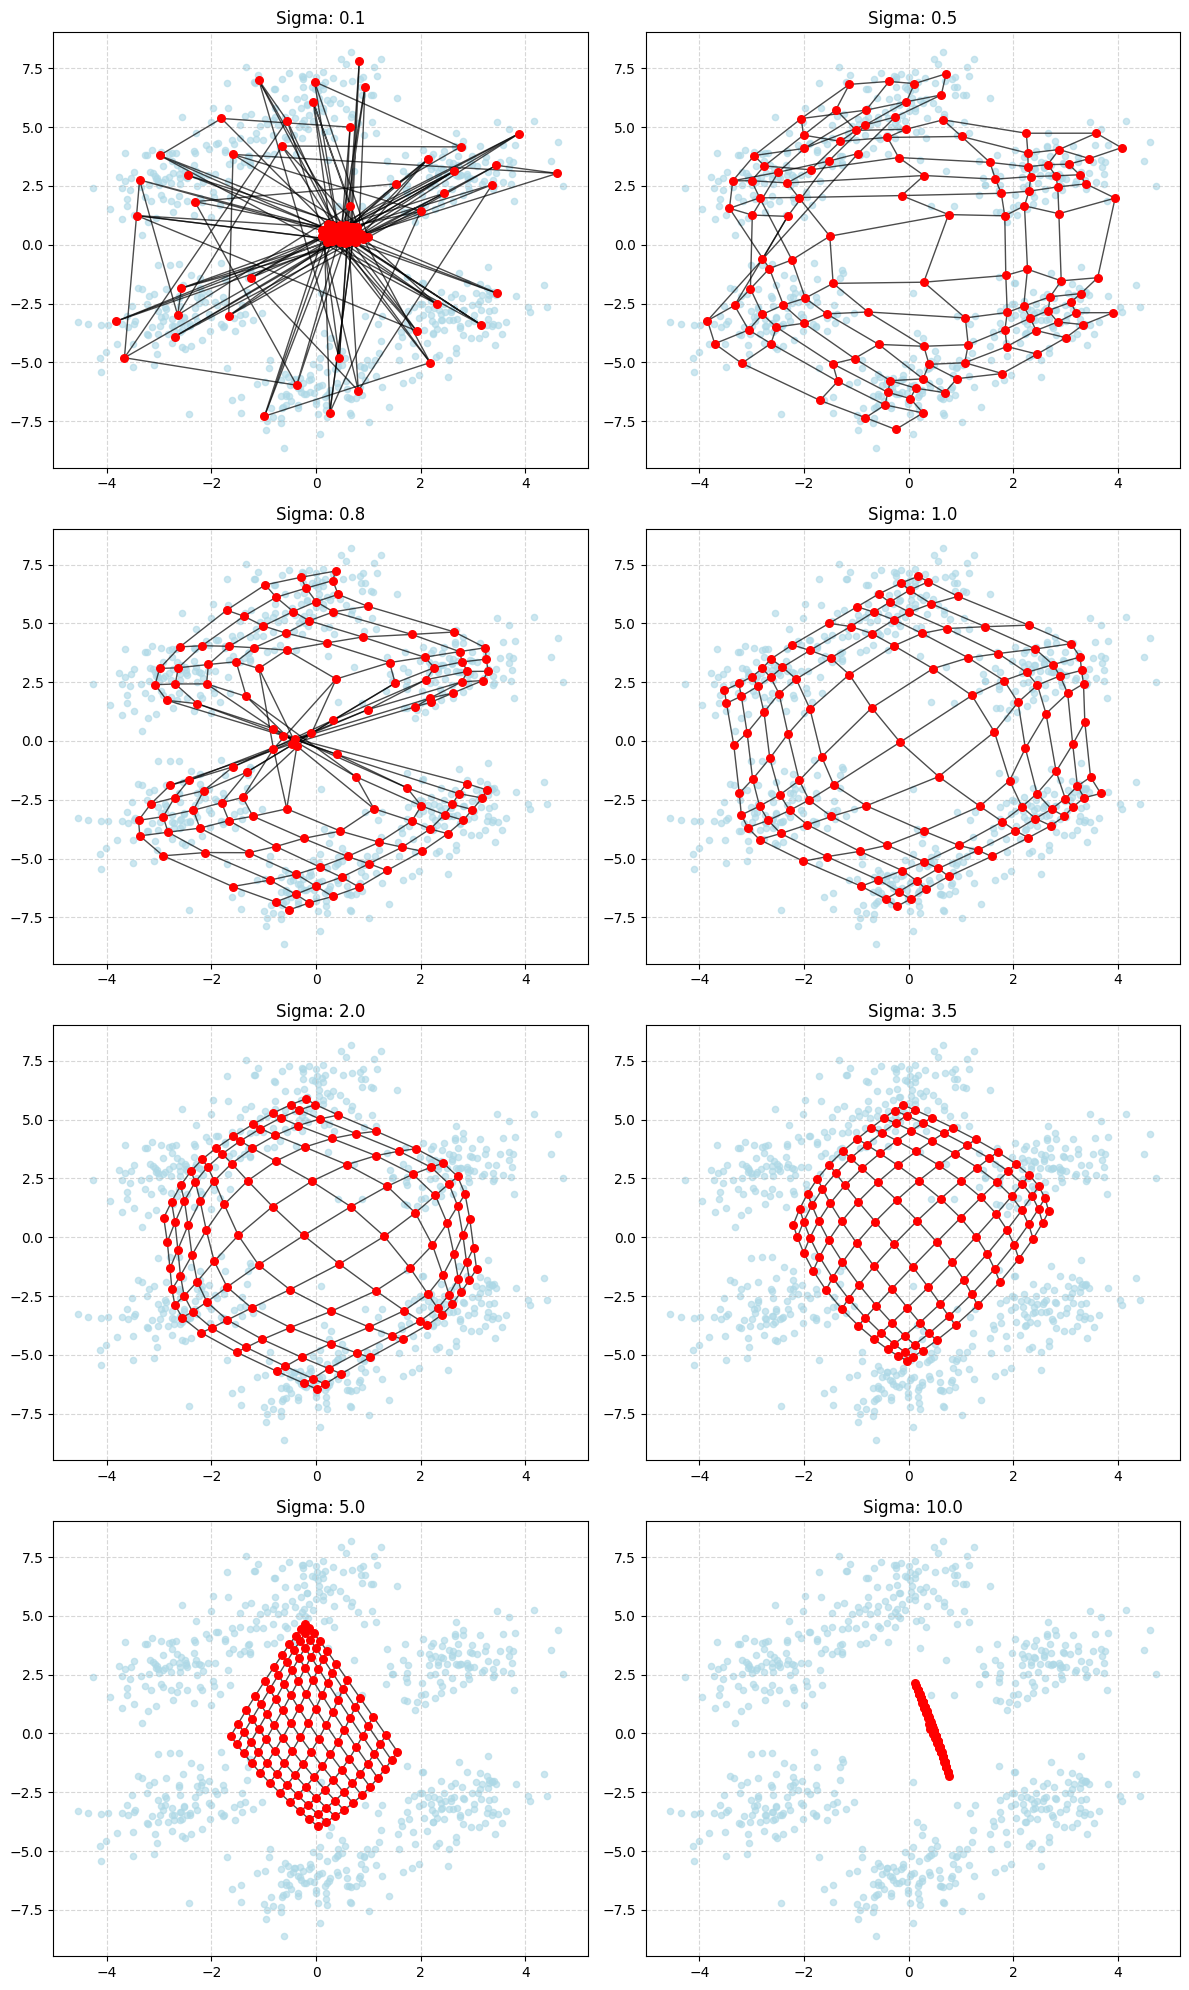

In [11]:
sigmas_to_test = [0.1, 0.5, 0.8, 1.0, 2.0, 3.5, 5.0, 10.0]

n_cols = 2
n_rows = int(np.ceil(len(sigmas_to_test) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 5 * n_rows))

axes_flat = axes.flatten()

for ax, test_sigma in zip(axes_flat, sigmas_to_test):

    print(f"Training SOM with sigma = {test_sigma}...")

    som = KohonenNetwork(
        grid_shape=(11, 11),
        input_dim=2,
        lambda_param=30000,
        neighborhood_type='gaussian'
    )

    som.train(data=hexagon_features, num_epochs=100, sigma=test_sigma)

    plot_som_2d_on_axis(
        ax=ax,
        data=hexagon_features,
        weights=som.weights,
        title=f"Sigma: {test_sigma}"
    )

for i in range(len(sigmas_to_test), len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

Training SOM with sigma = 0.1...
Training SOM with sigma = 1.0...
Training SOM with sigma = 5.0...
Training SOM with sigma = 7.5...
Training SOM with sigma = 8.0...
Training SOM with sigma = 8.5...
Training SOM with sigma = 9.0...
Training SOM with sigma = 10.0...


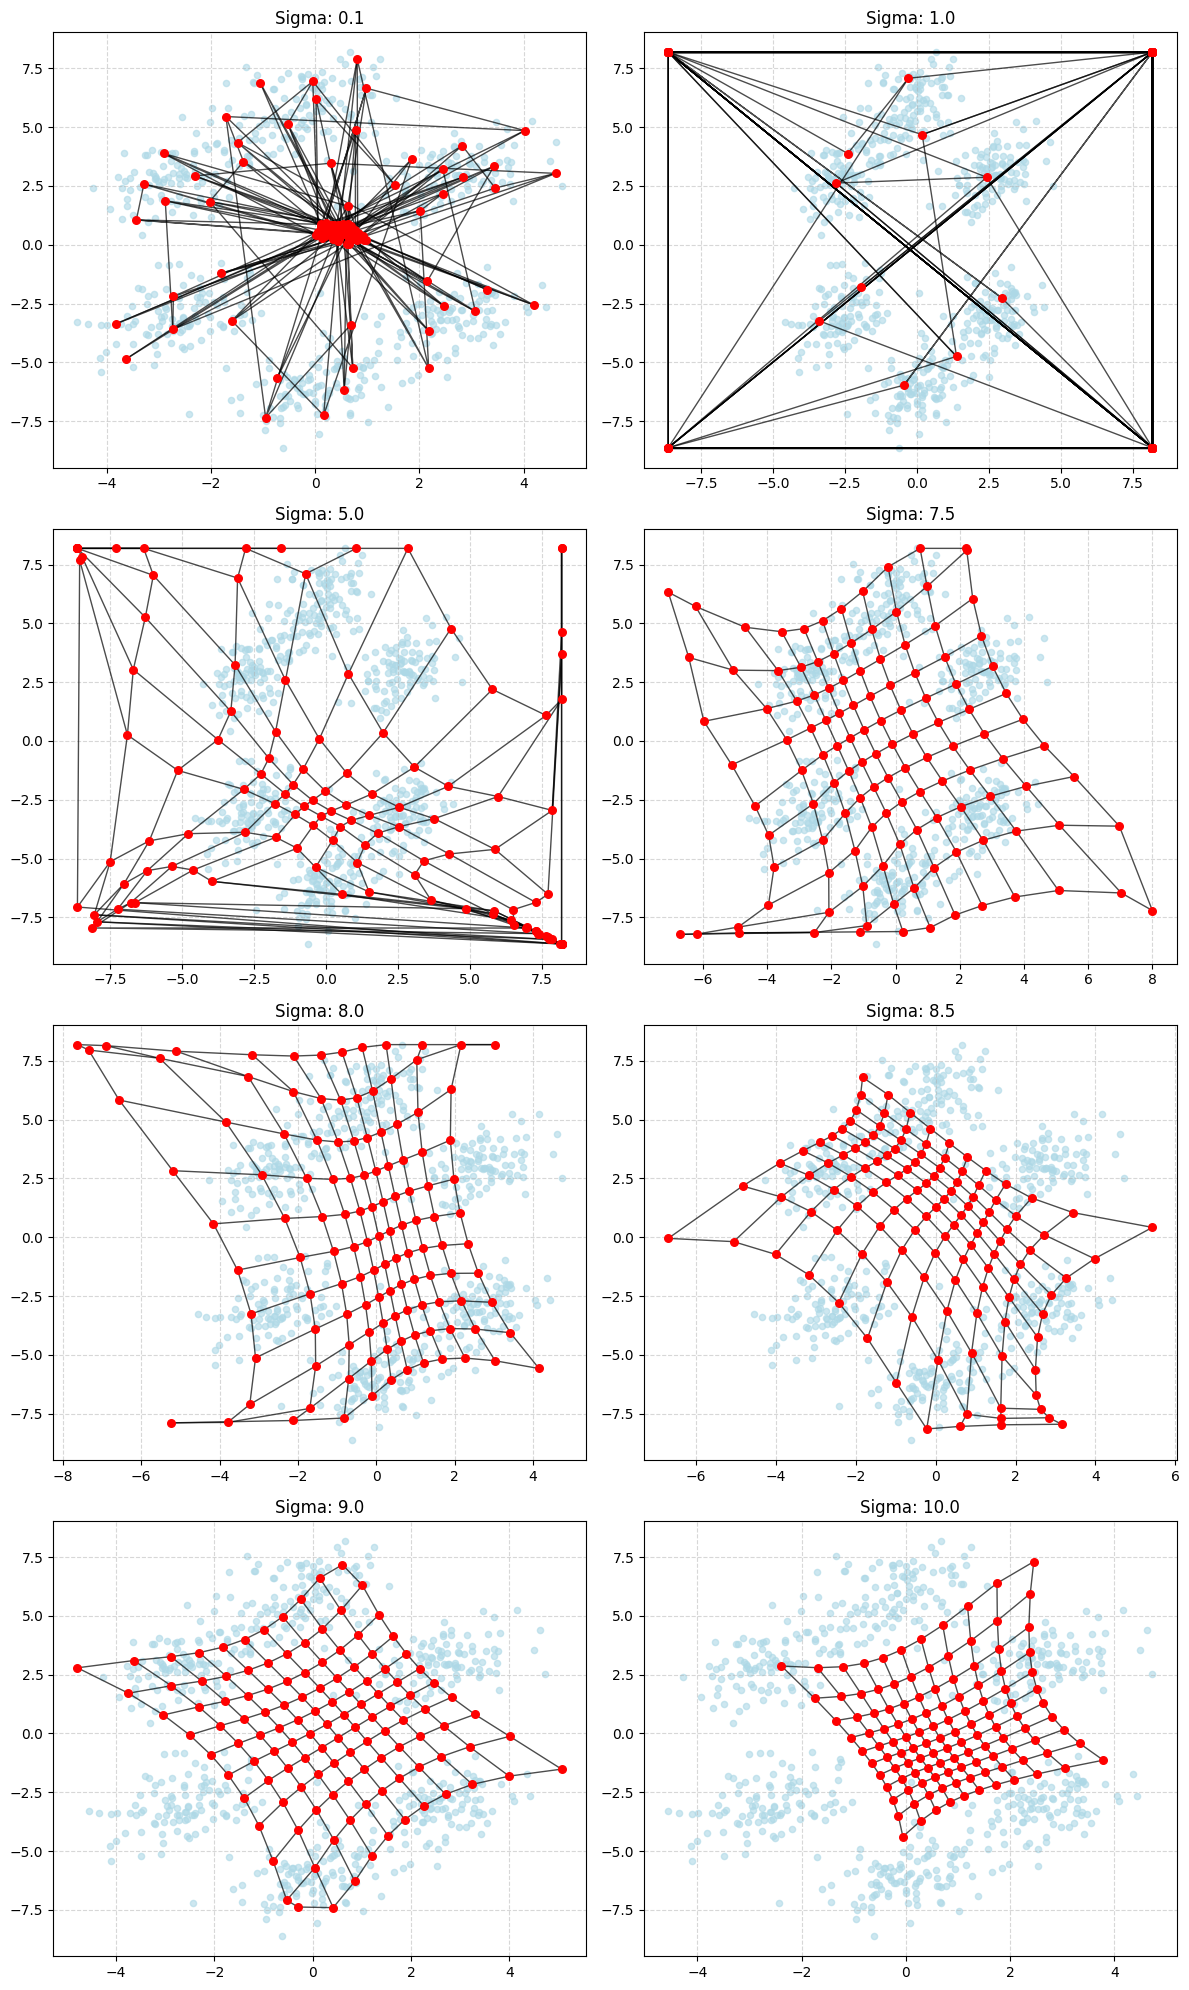

In [12]:
sigmas_to_test = [0.1, 1.0, 5.0, 7.5, 8.0, 8.5, 9.0, 10.0]

n_cols = 2
n_rows = int(np.ceil(len(sigmas_to_test) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 5 * n_rows))

axes_flat = axes.flatten()

for ax, test_sigma in zip(axes_flat, sigmas_to_test):

    print(f"Training SOM with sigma = {test_sigma}...")

    som = KohonenNetwork(
        grid_shape=(11, 11),
        input_dim=2,
        lambda_param=50000,
        neighborhood_type='mexican_hat'
    )

    som.train(data=hexagon_features, num_epochs=100, sigma=test_sigma)

    plot_som_2d_on_axis(
        ax=ax,
        data=hexagon_features,
        weights=som.weights,
        title=f"Sigma: {test_sigma}"
    )

for i in range(len(sigmas_to_test), len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()

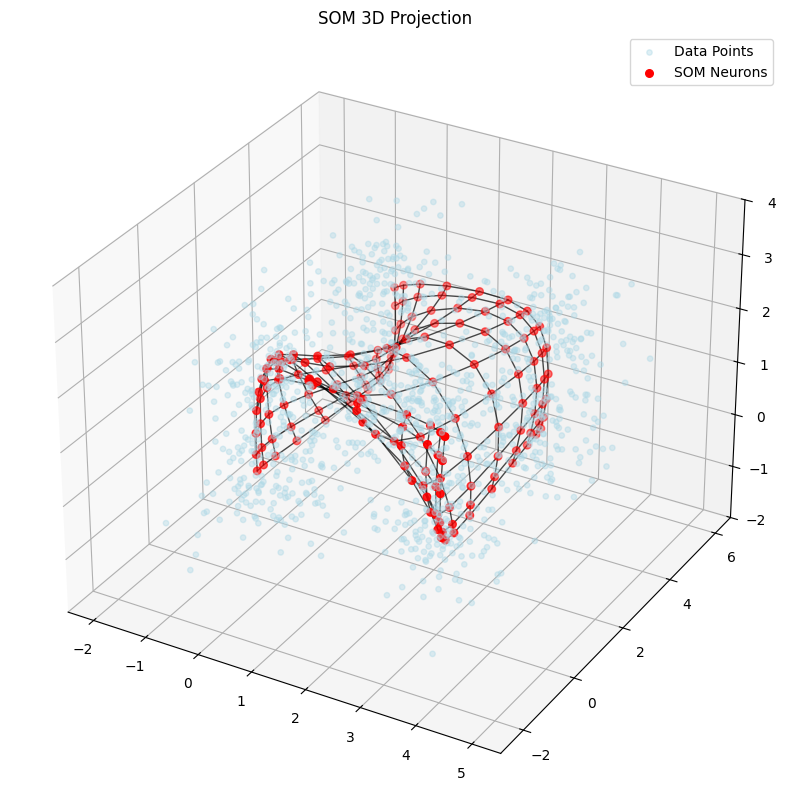

In [22]:
som_cube = KohonenNetwork(grid_shape=(13, 13), input_dim=3, lambda_param=60000)

som_cube.train(data=cube_features, num_epochs=100, sigma=2)

cube_predictions = som_cube.predict(cube_features)

plot_som_3d(cube_features, som_cube.weights)

In [23]:
info, purity = evaluate_som_clusters(cube_predictions, true_labels=cube_labels)

Total active neurons: 154

Neuron (0, 0): 36 samples, Purity: 97.22% | Counts: {2: 1, 3: 35}
Neuron (0, 1): 14 samples, Purity: 100.00% | Counts: {3: 14}
Neuron (0, 2): 20 samples, Purity: 100.00% | Counts: {3: 20}
Neuron (0, 3): 15 samples, Purity: 100.00% | Counts: {3: 15}
Neuron (0, 4): 1 samples, Purity: 100.00% | Counts: {1: 1}
Neuron (0, 5): 6 samples, Purity: 100.00% | Counts: {1: 6}
Neuron (0, 6): 21 samples, Purity: 100.00% | Counts: {1: 21}
Neuron (0, 7): 15 samples, Purity: 100.00% | Counts: {1: 15}
Neuron (0, 8): 18 samples, Purity: 100.00% | Counts: {1: 18}
Neuron (0, 9): 9 samples, Purity: 100.00% | Counts: {1: 9}
Neuron (0, 10): 6 samples, Purity: 66.67% | Counts: {1: 4, 5: 2}
Neuron (0, 11): 7 samples, Purity: 100.00% | Counts: {5: 7}
Neuron (0, 12): 26 samples, Purity: 100.00% | Counts: {5: 26}
Neuron (1, 0): 13 samples, Purity: 92.31% | Counts: {3: 12, 7: 1}
Neuron (1, 1): 3 samples, Purity: 100.00% | Counts: {3: 3}
Neuron (1, 2): 5 samples, Purity: 100.00% | Counts: 

In [16]:
def plot_u_matrix(som, title="U-Matrix"):
    """
    Calculates and plots the U-Matrix of the SOM.
    Large values represent boundaries, small values represent clusters.
    """
    M, N, _ = som.weights.shape
    u_matrix = np.zeros((M, N))

    for i in range(M):
        for j in range(N):
            current_weight = som.weights[i, j]
            neighbor_distances = []

            # Check all 8 neighbors (including diagonals)
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0: continue
                    ni, nj = i + di, j + dj

                    if 0 <= ni < M and 0 <= nj < N:
                        neighbor_weight = som.weights[ni, nj]
                        dist = np.linalg.norm(current_weight - neighbor_weight)
                        neighbor_distances.append(dist)

            u_matrix[i, j] = np.mean(neighbor_distances)

    plt.figure(figsize=(7, 6))
    plt.pcolor(u_matrix, cmap='viridis') # 'viridis' is great for depth
    plt.colorbar(label='Average distance to neighbors')
    plt.title(title)
    plt.show()

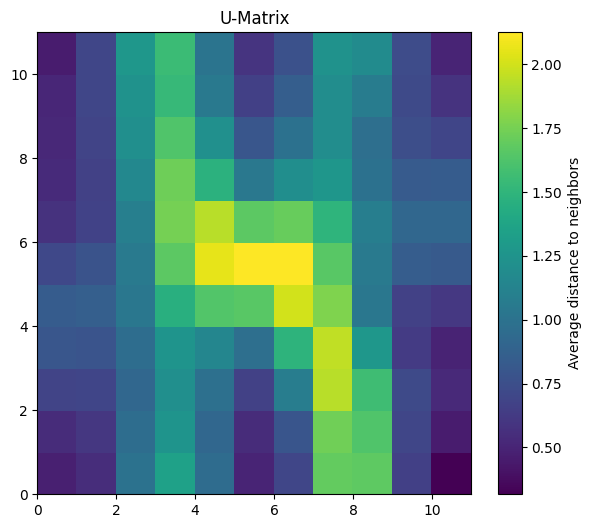

In [17]:
plot_u_matrix(som_hexagon)

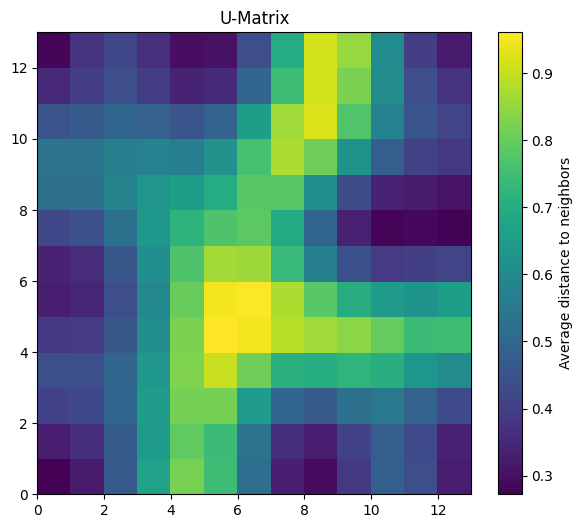

In [24]:
plot_u_matrix(som_cube)